**CAR PRICE PREDICTION**

Importing dependancies

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

Data Collection and Preproccessing


In [79]:
#Loading dataset from csv file to pandas dataframe
car_data = pd.read_csv('/content/cardata.csv')

In [80]:
#Going throw first five rows of dataset
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
#Size of the dataset
car_data.shape

(301, 9)

In [81]:
#Required info of dataset
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [82]:
#checking for missing values in each column
print(car_data.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [83]:
#Counting each type of some non number columns
print(car_data.Fuel_Type.value_counts())
print(car_data.Seller_Type.value_counts())
print(car_data.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [85]:
#Converting objects into integers
print(car_data.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':3}},inplace=True))
print(car_data.replace({'Seller_Type':{'Individual':0,'Dealer':1}},inplace=True))
print(car_data.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True))

None
None
None


In [ ]:
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,1,0,0
1,sx4,2013,4.75,9.54,43000,1,1,0,0
2,ciaz,2017,7.25,9.85,6900,0,1,0,0
3,wagon r,2011,2.85,4.15,5200,0,1,0,0
4,swift,2014,4.60,6.87,42450,1,1,0,0


Splitting data into trainning set and test set


In [63]:
#Splitting Columns for training
X = car_data.drop(['Selling_Price', 'Car_Name'], axis=1)
Y = car_data[['Selling_Price']]


In [64]:
print(X.head())
print(Y.head())

   Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0  2014           5.59       27000          0            1             0   
1  2013           9.54       43000          1            1             0   
2  2017           9.85        6900          0            1             0   
3  2011           4.15        5200          0            1             0   
4  2014           6.87       42450          1            1             0   

   Owner  
0      0  
1      0  
2      0  
3      0  
4      0  
   Selling_Price
0           3.35
1           4.75
2           7.25
3           2.85
4           4.60


In [100]:
#Splitting rows into trainning set and testing set
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1,random_state=2)

Linear Regression Model Trainning

In [101]:
#Loading linear reggresion model.
my_model = LinearRegression()

In [102]:
my_model.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [103]:
my_prediction = my_model.predict(X_train)

In [104]:
my_error_score = metrics.r2_score(Y_train,my_prediction)

In [105]:
print(my_error_score)

0.877773518284606


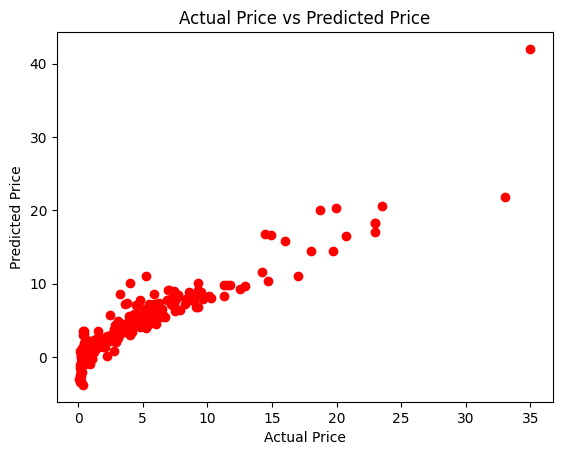

In [106]:
#Plotting scatter plot between actual price and predicted price
plt.scatter(Y_train,my_prediction, c='r',marker='o')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

In [107]:
my_model.fit(X_test,Y_test)

LinearRegression()

In [108]:
my_test_prediction = my_model.predict(X_test)

In [109]:
my_error_score = metrics.r2_score(Y_test,my_test_prediction)

In [110]:
print(my_error_score)

0.9624543729356931


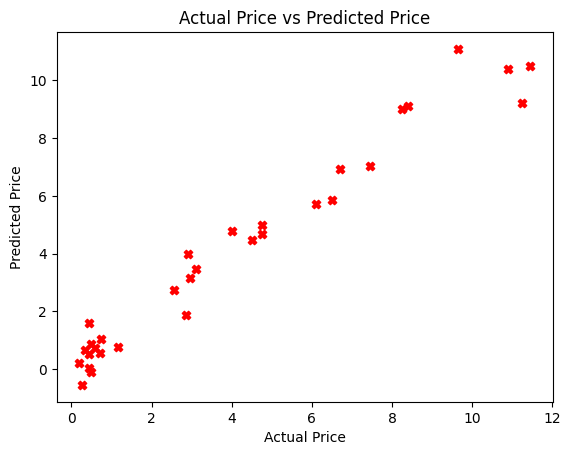

In [111]:
plt.scatter(Y_test,my_test_prediction, c='r',marker='X')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()